In [4]:
!pip install pysdd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.3/502.3 kB 14.1 MB/s eta 0:00:00


In [2]:
pip install pysdd

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 28.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   ---------------------------------------- 0/2 [cython]
   -------------------- ------------------- 1/2 [pysdd]

In [3]:
from pysdd.sdd import SddManager, Vtree, WmcManager
print("PySDD installed successfully")

PySDD installed successfully


NN2Logic Multi-Layer XOR Experiment


Model: "nn2logic_feedforward"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


FORWARD PROPAGATION TEST
  Input: [0 0]  Hidden: [0.5 0.5 0.5 0.5]  Output: 0.6489 → class=1
  Input: [0 1]  Hidden: [0.7193 0.5281 0.3389 0.5046]  Output: 0.5940 → class=1
  Input: [1 0]  Hidden: [0.5093 0.376  0.7202 0.5337]  Output: 0.6414 → class=1
  Input: [1 1]  Hidden: [0.7268 0.4027 0.5689 0.5383]  Output: 0.5870 → class=1

[Attempt 1] best_epoch=189 best_acc=1.0000 last_epoch=10000
 Converged at epoch 189.

XOR Predictions:
  x=[0 0] label=0 pred=0 Yes
  x=[0 1] label=1 pred=1 Yes
  x=[1 0] label=1 pred=1 Yes
  x=[1 1] label=0 pred=0 Yes
Training verified — network correctly learned XOR. Pipeline starting.


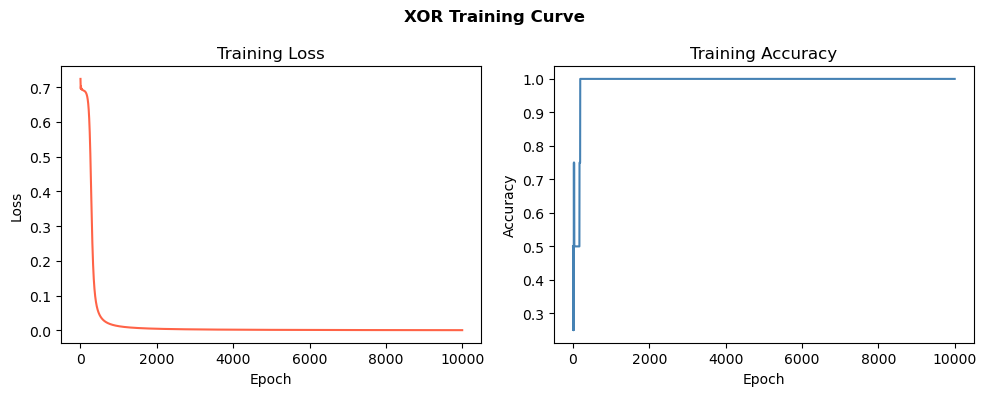

  Saved --> training_curve_multilayer.png

Extracted weights:

Layer: hidden_layer  |  Inputs: 2  |  Neurons: 4
  W:
[[-6.6114 -7.9223  1.0792  3.3443]
 [ 7.853   6.686  -2.4321  3.3568]]
  b: [ 3.1934 -3.1858 -0.5491 -0.2965]

Layer: output_layer  |  Inputs: 4  |  Neurons: 1
  W:
[[-13.7647]
 [ 14.9771]
 [  2.2916]
 [  4.5626]]
  b: [1.8399]

Building ACs (dynamic layer traversal)...

Layer [1]: hidden_layer  (inputs=2, neurons=4)
  Input var names: ['x1', 'x2']
  Neuron 1: nodes=9  w=[-6.611  7.853]  b=3.193
  Neuron 2: nodes=9  w=[-7.922  6.686]  b=-3.186
  Neuron 3: nodes=9  w=[ 1.079 -2.432]  b=-0.549
  Neuron 4: nodes=9  w=[3.344 3.357]  b=-0.297

Layer [2]: output_layer  (inputs=4, neurons=1)
  Input var names: ['l1_h1', 'l1_h2', 'l1_h3', 'l1_h4']
  Neuron 1: nodes=15  w=[-13.765  14.977   2.292   4.563]  b=1.84

Total ACs built: 5

Compiling ACs to NNF (OBDD algorithm)...
  hidden_layer neuron 1: NNF nodes=10  satisfying=3/4
  hidden_layer neuron 2: NNF nodes=4  satisfying=1/4


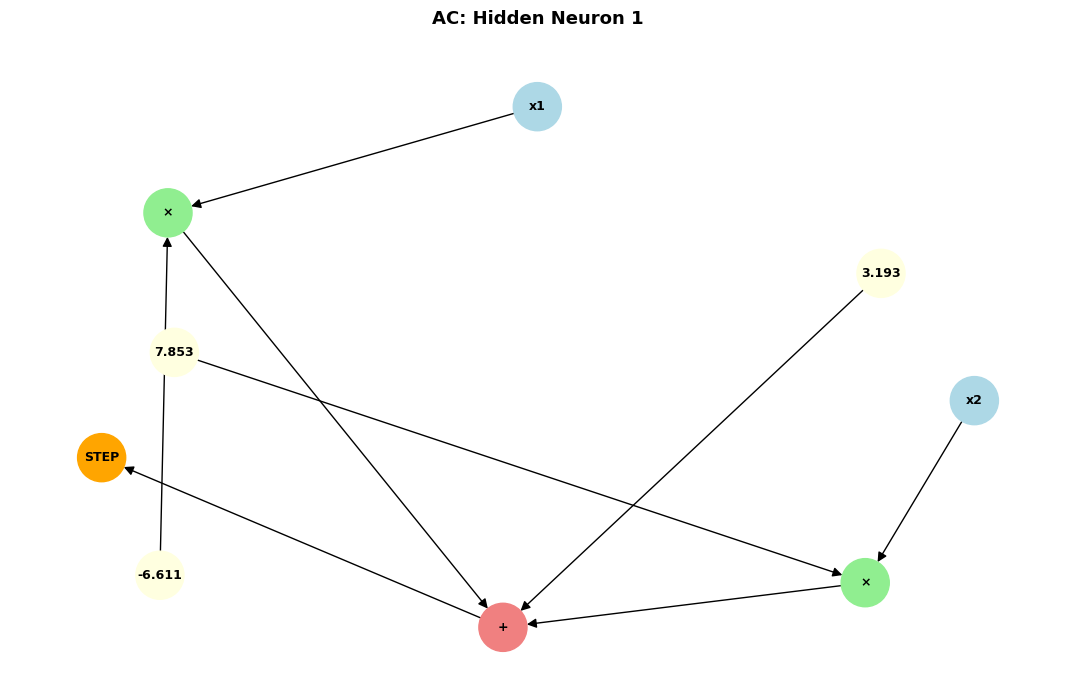

  Saved --> ac_hidden_1.png


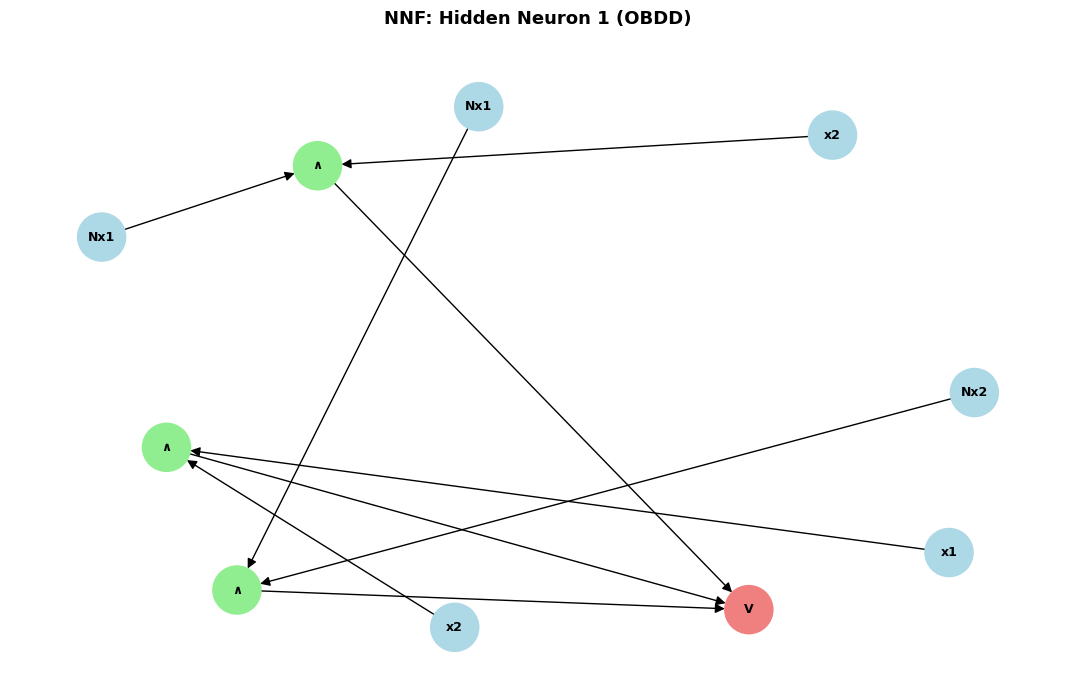

  Saved --> nnf_hidden_1.png


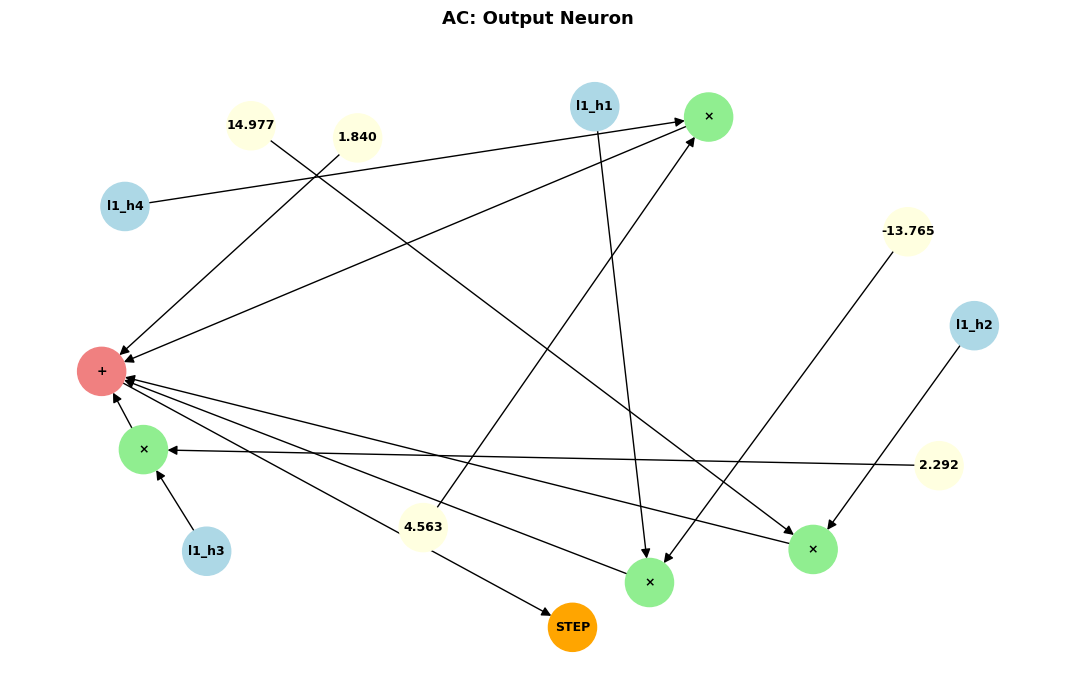

  Saved --> ac_output.png


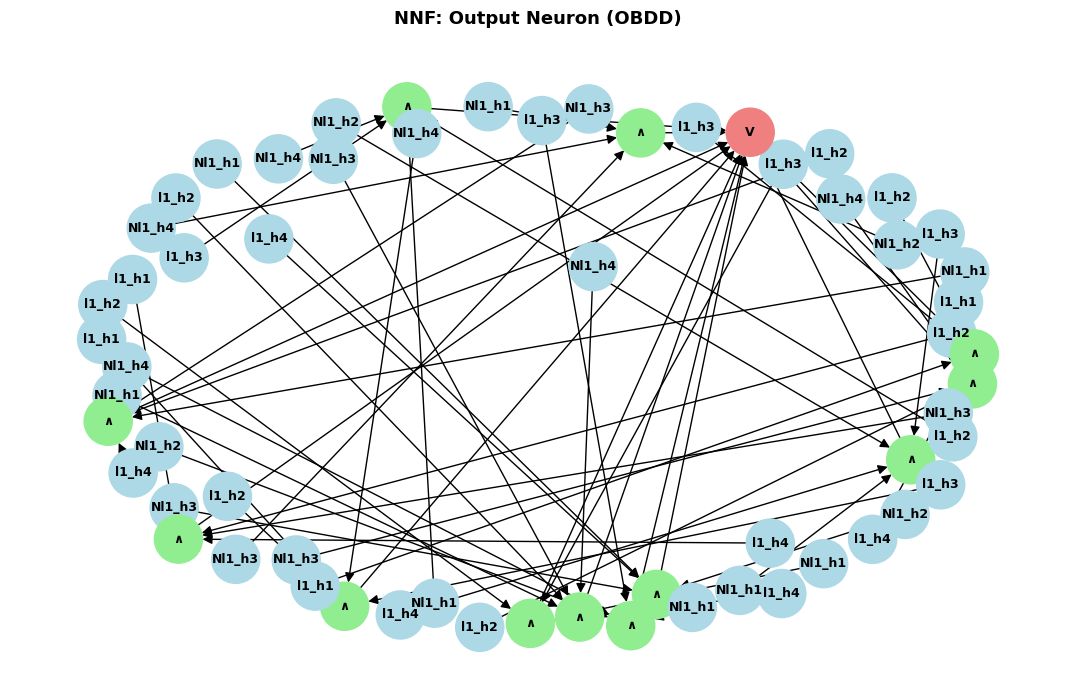

  Saved --> nnf_output.png


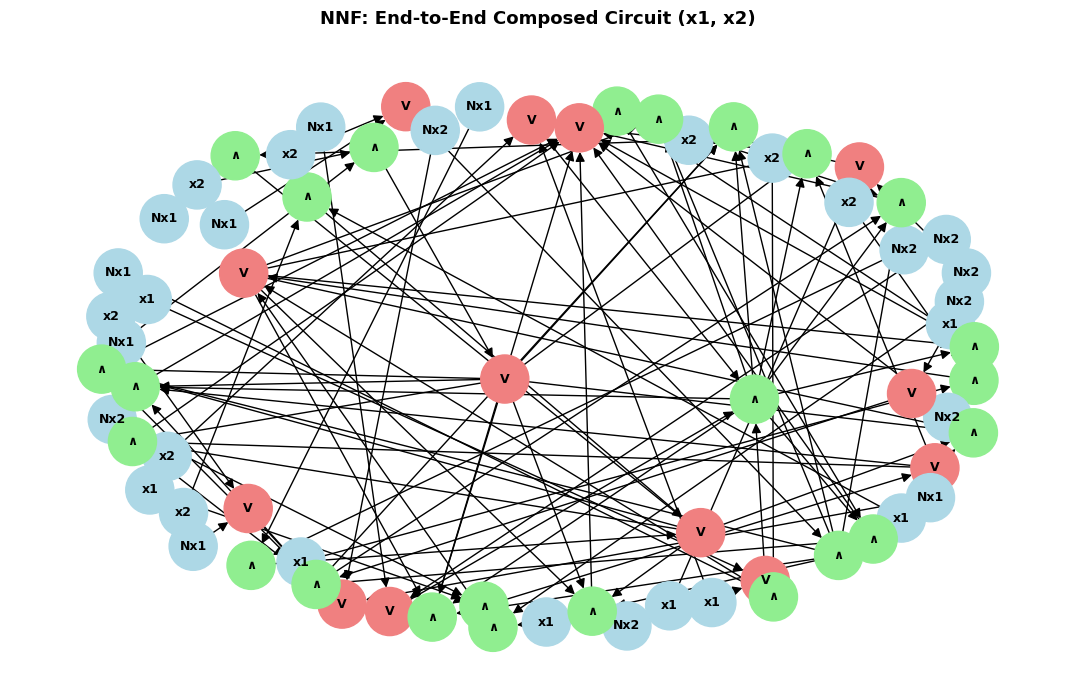

  Saved --> nnf_composed.png


In [7]:
# ============================================================
#  IMPORTS
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import tensorflow as tf
from tensorflow import keras
import networkx as nx
import matplotlib.pyplot as plt

try:
    from pysdd.sdd import SddManager, Vtree, WmcManager
    PYSDD_AVAILABLE = True
except ImportError:
    PYSDD_AVAILABLE = False
    print("[WARNING] PySDD not installed. Run: pip install pysdd")

print("NN2Logic Multi-Layer XOR Experiment")


# ============================================================
#  DATA STRUCTURES
# ============================================================
class ACNode:
    def __init__(self, id, op, inputs=None, value=None):
        self.id     = id
        self.op     = op
        self.inputs = inputs or []
        self.value  = value

class NNFNode:
    def __init__(self, id, op, inputs=None, literal=None):
        self.id      = id
        self.op      = op
        self.inputs  = inputs or []
        self.literal = literal

class AC:
    def __init__(self):
        self.nodes  = []
        self.count  = 0
        self.output = None

    def add(self, op, **kw):
        n = ACNode(f"n{self.count + 1}", op, **kw)
        self.nodes.append(n)
        self.count += 1
        return n

class NNF:
    def __init__(self, n_vars):
        self.nodes  = []
        self.count  = 0
        self.output = None
        self.n_vars = n_vars

    def add(self, op, **kw):
        n = NNFNode(self.count, op, **kw)
        self.nodes.append(n)
        self.count += 1
        return n


# ============================================================
#  UTILITIES
# ============================================================
def get_all_binary_inputs(n):
    if n > 20:
        raise ValueError(
            f"Exhaustive enumeration for {n} variables = {2**n} combinations. "
            "Use OBDD algorithm directly for large n."
        )
    return [[int(b) for b in format(i, f'0{n}b')] for i in range(2**n)]


# ============================================================
#  AC EVALUATION
# ============================================================
def eval_ac(ac, vals):
    v = {}
    for n in ac.nodes:
        if   n.op == "INPUT": v[n.id] = vals[n.value]
        elif n.op == "CONST": v[n.id] = n.value
        elif n.op == "MUL":   v[n.id] = v[n.inputs[0].id] * v[n.inputs[1].id]
        elif n.op == "ADD":   v[n.id] = sum(v[i.id] for i in n.inputs)
        elif n.op == "ACT":   v[n.id] = 1 if v[n.inputs[0].id] >= 0 else 0
    return v[ac.output.id]


# ============================================================
#  NNF EVALUATOR
# ============================================================
def eval_nnf(nnf, vals, var_names):
    v = {}
    for n in nnf.nodes:
        if n.op == "LITERAL":
            idx     = abs(n.literal) - 1
            val     = vals[var_names[idx]]
            v[n.id] = val if n.literal > 0 else 1 - val
        elif n.op == "AND":
            v[n.id] = 1 if all(v[i.id] for i in n.inputs) else 0
        elif n.op == "OR":
            v[n.id] = 1 if any(v[i.id] for i in n.inputs) else 0
    return v[nnf.output.id] if nnf.output is not None else 0


# ============================================================
#  OBDD ALGORITHM
# ============================================================
def _to_integers(weights, bias, scale_override=None):
    if scale_override is not None:
        return ([int(round(w * scale_override)) for w in weights],
                int(round(bias * scale_override)))
    all_vals   = [abs(w) for w in weights] + [abs(bias)]
    non_zero   = [v for v in all_vals if v > 1e-9]
    safe_scale = max(1000, int(100.0 / min(non_zero)) + 1) if non_zero else 1000
    return ([int(round(w * safe_scale)) for w in weights],
            int(round(bias * safe_scale)))


def compile_neuron_obdd(weights, bias, var_names, scale_override=None):
    n            = len(weights)
    int_w, int_b = _to_integers(weights, bias, scale_override)
    states = {int_b: [[]]}
    for i, w in enumerate(int_w):
        next_states = {}
        for acc_sum, paths in states.items():
            for path in paths:
                next_states.setdefault(acc_sum,     []).append(path + [-(i + 1)])
                next_states.setdefault(acc_sum + w, []).append(path + [ (i + 1)])
        states = next_states
    nnf       = NNF(n)
    and_terms = []
    for acc_sum, paths in states.items():
        if acc_sum >= 0:
            for path in paths:
                lits = [nnf.add("LITERAL", literal=lit) for lit in path]
                and_terms.append(nnf.add("AND", inputs=lits))
    nnf.output = nnf.add("OR", inputs=and_terms)
    return nnf


def compile_neuron_obdd_verified(weights, bias, var_names):
    ac_ref  = build_ac_for_neuron(weights, bias, var_names)
    all_inp = get_all_binary_inputs(len(var_names))
    ac_sat  = sum(1 for inp in all_inp
                  if eval_ac(ac_ref, dict(zip(var_names, inp))) == 1)
    for scale in [1000, 10000, 100000]:
        nnf     = compile_neuron_obdd(weights, bias, var_names, scale_override=scale)
        nnf_sat = sum(1 for inp in all_inp
                      if eval_nnf(nnf, dict(zip(var_names, inp)), var_names) == 1)
        if nnf_sat == ac_sat:
            return nnf
        print(f"    [scale={scale}] NNF sat={nnf_sat} != AC sat={ac_sat}, retrying...")
    raise RuntimeError(
        f"compile_neuron_obdd_verified failed for weights={weights} "
        f"bias={bias} after scale escalation. AC sat={ac_sat}."
    )


# ============================================================
#  NNF COMPOSITION
# ============================================================
def _copy_nnf_into(src_node, src_nnf, dst_nnf, memo):
    key = (id(src_nnf), src_node.id)
    if key in memo:
        return memo[key]
    if src_node.op == "LITERAL":
        new_node = dst_nnf.add("LITERAL", literal=src_node.literal)
    elif src_node.op in ("AND", "OR"):
        copied = [_copy_nnf_into(c, src_nnf, dst_nnf, memo) for c in src_node.inputs]
        new_node = dst_nnf.add(src_node.op, inputs=copied)
    else:
        new_node = dst_nnf.add(src_node.op)
    memo[key] = new_node
    return new_node


def _negate_nnf_node(nnf_out, node, src_nnf, memo):
    key = (id(src_nnf), node.id)
    if key in memo:
        return memo[key]
    if node.op == "LITERAL":
        new_node = nnf_out.add("LITERAL", literal=-node.literal)
    elif node.op == "AND":
        neg_ch   = [_negate_nnf_node(nnf_out, c, src_nnf, memo) for c in node.inputs]
        new_node = nnf_out.add("OR", inputs=neg_ch)
    elif node.op == "OR":
        neg_ch   = [_negate_nnf_node(nnf_out, c, src_nnf, memo) for c in node.inputs]
        new_node = nnf_out.add("AND", inputs=neg_ch)
    else:
        new_node = node
    memo[key] = new_node
    return new_node


def compose_nnfs(output_nnf, hidden_nnfs, n_original_vars):
    composed         = NNF(n_original_vars)
    shared_copy_memo = {}
    shared_neg_memo  = {}
    hidden_roots     = {}
    hidden_neg_roots = {}

    for idx, h_nnf in enumerate(hidden_nnfs):
        all_inp     = get_all_binary_inputs(h_nnf.n_vars)
        var_names_h = [f"x{i+1}" for i in range(h_nnf.n_vars)]
        sat = sum(1 for inp in all_inp
                  if eval_nnf(h_nnf, dict(zip(var_names_h, inp)), var_names_h) == 1)
        if sat == len(all_inp):
            hidden_roots[idx]     = composed.add("AND", inputs=[])
            hidden_neg_roots[idx] = composed.add("OR",  inputs=[])
        elif sat == 0:
            hidden_roots[idx]     = composed.add("OR",  inputs=[])
            hidden_neg_roots[idx] = composed.add("AND", inputs=[])
        else:
            hidden_roots[idx]     = _copy_nnf_into(
                                        h_nnf.output, h_nnf, composed, shared_copy_memo)
            hidden_neg_roots[idx] = _negate_nnf_node(
                                        composed, hidden_roots[idx], h_nnf, shared_neg_memo)

    def substitute(node, memo):
        if node.id in memo:
            return memo[node.id]
        if node.op == "LITERAL":
            hi_idx = abs(node.literal) - 1
            if hi_idx < len(hidden_nnfs):
                new_node = hidden_roots[hi_idx] if node.literal > 0 \
                           else hidden_neg_roots[hi_idx]
            else:
                sign     = 1 if node.literal > 0 else -1
                new_node = composed.add("LITERAL", literal=sign * (hi_idx + 1))
        elif node.op in ("AND", "OR"):
            sub_ch   = [substitute(c, memo) for c in node.inputs]
            new_node = composed.add(node.op, inputs=sub_ch)
        else:
            new_node = composed.add(node.op)
        memo[node.id] = new_node
        return new_node

    composed.output = substitute(output_nnf.output, {})
    return composed


# ============================================================
#  FILE I/O
# ============================================================
def write_ac(ac, file):
    with open(file, "w") as f:
        f.write("AC_FORMAT\nVERSION 1.0\n\n")
        for n in ac.nodes:
            if n.op in {"INPUT", "CONST"}:
                f.write(f"NODE {n.id} {n.op} {n.value}\n")
            elif n.op == "ACT":
                f.write(f"NODE {n.id} ACT {n.value} {n.inputs[0].id}\n")
            else:
                f.write(f"NODE {n.id} {n.op} {' '.join(i.id for i in n.inputs)}\n")
        f.write(f"\nOUTPUT {ac.output.id}\n")


def write_nnf(nnf, file):
    edges = sum(len(n.inputs) for n in nnf.nodes if n.inputs)
    with open(file, "w") as f:
        f.write(f"nnf {len(nnf.nodes)} {edges} {nnf.n_vars}\n")
        for n in nnf.nodes:
            if   n.op == "LITERAL": f.write(f"L {n.literal}\n")
            elif n.op == "AND":     f.write(f"A {len(n.inputs)} {' '.join(str(i.id) for i in n.inputs)}\n")
            elif n.op == "OR":      f.write(f"O 0 {len(n.inputs)} {' '.join(str(i.id) for i in n.inputs)}\n")


# ============================================================
#  VISUALIZATION
# ============================================================
def visualize(circuit, var_names=None, title="", filename="graph.png"):
    G, labels, colors = nx.DiGraph(), {}, []
    for n in circuit.nodes:
        G.add_node(n.id)
        if isinstance(circuit, AC):
            if   n.op == "INPUT": labels[n.id], col = n.value, 'lightblue'
            elif n.op == "CONST": labels[n.id], col = f"{n.value:.3f}", 'lightyellow'
            elif n.op == "MUL":   labels[n.id], col = "×", 'lightgreen'
            elif n.op == "ADD":   labels[n.id], col = "+", 'lightcoral'
            elif n.op == "ACT":   labels[n.id], col = n.value, 'orange'
            else:                 labels[n.id], col = n.op, 'white'
        else:
            if n.op == "LITERAL":
                idx   = abs(n.literal)
                vname = var_names[idx-1] if var_names and idx-1 < len(var_names) else f"x{idx}"
                labels[n.id] = vname if n.literal > 0 else f"N{vname}"
                col = 'lightblue'
            elif n.op == "AND": labels[n.id], col = "∧", 'lightgreen'
            elif n.op == "OR":  labels[n.id], col = "V", 'lightcoral'
            else:               labels[n.id], col = n.op, 'white'
        colors.append(col)
        for inp in n.inputs:
            G.add_edge(inp.id, n.id)
    fig = plt.figure(figsize=(11, 7))
    fig.subplots_adjust(top=0.92, bottom=0.02, left=0.02, right=0.98)
    ax  = fig.add_subplot(111)
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, ax=ax, labels=labels, node_color=colors,
            node_size=1200, font_size=9, font_weight='bold',
            arrows=True, arrowsize=14)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.98)
    plt.savefig(filename, dpi=150); plt.show()
    print(f"  Saved --> {filename}")


# ============================================================
#  SDD FUNCTIONS  (Phase 3)
# ============================================================
def nnf_to_sdd(nnf_circuit, manager):
    cache = {}

    def compile_node(node):
        if node.id in cache:
            return cache[node.id]
        if node.op == "LITERAL":
            result = manager.literal(node.literal)
        elif node.op == "AND":
            result = manager.true() if not node.inputs else compile_node(node.inputs[0])
            for child in node.inputs[1:]:
                result = result.conjoin(compile_node(child))
        elif node.op == "OR":
            result = manager.false() if not node.inputs else compile_node(node.inputs[0])
            for child in node.inputs[1:]:
                result = result.disjoin(compile_node(child))
        else:
            raise ValueError(f"Unknown NNF op: {node.op}")
        cache[node.id] = result
        return result

    if nnf_circuit.output is None:
        raise ValueError("NNF circuit has no output node set.")
    return compile_node(nnf_circuit.output)


def eval_sdd(sdd_root, manager, var_names, vals):
    node = sdd_root
    for i, vname in enumerate(var_names):
        lit  = (i + 1) if vals[vname] == 1 else -(i + 1)
        node = node.condition(lit)
    return 1 if node.is_true() else 0


def write_sdd_dot(sdd_root, vtree,
                  filename_sdd="network_sdd.dot",
                  filename_vtree="network_vtree.dot"):
    with open(filename_sdd, "w") as f:
        print(sdd_root.dot(), file=f)
    with open(filename_vtree, "w") as f:
        print(vtree.dot(), file=f)
    print(f"  Saved SDD   dot --> {filename_sdd}")
    print(f"  Saved Vtree dot --> {filename_vtree}")


def sdd_robustness_analysis(sdd_root, manager, var_names, all_inputs):
    results = {}
    for inp in all_inputs:
        vals = dict(zip(var_names, inp))
        out  = eval_sdd(sdd_root, manager, var_names, vals)
        sens = []
        for vname in var_names:
            flipped        = dict(vals)
            flipped[vname] = 1 - flipped[vname]
            if eval_sdd(sdd_root, manager, var_names, flipped) != out:
                sens.append(vname)
        results[tuple(inp)] = {'output': out, 'sensitive_vars': sens}
    return results


def sdd_prime_implicants(sdd_root, manager, var_names, all_inputs):
    pis        = []
    sat_inputs = [inp for inp in all_inputs
                  if eval_sdd(sdd_root, manager, var_names,
                              dict(zip(var_names, inp))) == 1]
    for inp in sat_inputs:
        vals    = dict(zip(var_names, inp))
        minimal = set(var_names)
        for vname in var_names:
            candidate      = minimal - {vname}
            flipped        = dict(vals)
            flipped[vname] = 1 - flipped[vname]
            still_sat = all(
                eval_sdd(sdd_root, manager, var_names,
                         {v: vals[v] for v in var_names}) == 1
                for v in var_names
            )
            if still_sat and eval_sdd(
                sdd_root, manager, var_names,
                {v: (flipped[v] if v == vname else vals[v]) for v in var_names}
            ) == 1:
                minimal = candidate
        pis.append(frozenset(
            f"{v}={'1' if vals[v]==1 else '0'}" for v in minimal
        ))
    return list(set(pis))


# ============================================================
#  MODEL-BASED ROBUSTNESS 
# ============================================================
def model_based_robustness(sdd_root, manager, var_names):
    n     = len(var_names)
    total = 2 ** n

    h_prev       = sdd_root
    M            = 0
    level_counts = {}
    max_r        = 0

    print("\n" + "=" * 65)
    print("MODEL-BASED ROBUSTNESS  (Algorithm 1 — SSDC20)")
    print("=" * 65)
    print(f"  Variables : {var_names}")
    print(f"  n = {n},  total inputs = {total}")
    print(f"  Positive inputs (model count of f): {sdd_root.model_count()}")
    print()

    for k in range(2, n + 1):

        h_curr = manager.true()

        for i, vname in enumerate(var_names):
            lit_pos = i + 1
            lit_neg = -(i + 1)

            h_given_true  = h_prev.condition(lit_pos)
            h_given_false = h_prev.condition(lit_neg)
            robust_to_xi  = h_given_true.conjoin(h_given_false)
            h_curr        = h_curr.conjoin(robust_to_xi)

        f_k_minus_1 = h_prev.conjoin(h_curr.negate())
        mc          = f_k_minus_1.model_count()

        if mc > 0:
            level_counts[k - 1] = mc
            max_r = max(max_r, k - 1)

        M += (k - 1) * mc

        print(f"  k={k}: |h_{k}| = {h_curr.model_count():4d}  "
              f"|f_{k-1}| = {mc:4d}  "
              f"contribution = {(k-1)} x {mc} = {(k-1)*mc}")

        if h_curr.model_count() == 0:
            break

        h_prev = h_curr

    else:
        mc_n = h_prev.model_count()
        if mc_n > 0:
            level_counts[n] = mc_n
            max_r = max(max_r, n)
        M += n * mc_n
        print(f"  k={n} (final): |h_n| = {mc_n}  "
              f"contribution = {n} x {mc_n} = {n * mc_n}")

    mr = M / total

    print()
    print(f"  Robustness distribution:")
    for level, count in sorted(level_counts.items()):
        bar = '█' * count
        print(f"    r = {level}: {count:3d} input(s)  {bar}")

    print()
    print(f"  Total weighted sum M         = {M}")
    print(f"  Total inputs (2^n)           = {total}")
    print(f"  Model-Based Robustness mr(f) = {mr:.4f}")
    print(f"  Maximum Robustness           = {max_r}")
    print("=" * 65)

    return mr, max_r, level_counts


def run_model_robustness_report(sdd_root, manager, var_names):
    mr, max_r, level_counts = model_based_robustness(
        sdd_root, manager, var_names
    )
    n_positive = sdd_root.model_count()

    print("\n  SUMMARY — Model-Based Robustness")
    print("  " + "-" * 40)
    print(f"  Average robustness over all inputs : {mr:.4f}")
    print(f"  Maximum robustness                 : {max_r}")
    print(f"  Positive inputs (network fires)    : {n_positive} / {2**len(var_names)}")
    print()

    if level_counts:
        most_robust_level = max(level_counts.keys())
        print(f"  The most robust inputs require {most_robust_level} "
              f"bit flip(s) to change the classification.")
        print(f"  {level_counts[most_robust_level]} input(s) achieve this maximum robustness.")

    return mr, max_r, level_counts


# ============================================================
#  run_sdd_phase
# ============================================================
def run_sdd_phase(composed_nnf, network_var_names, all_inputs_orig, binarized_tf_fn):
    if not PYSDD_AVAILABLE:
        print("Skipping SDD phase — PySDD not installed.")
        return None, None

    n_vars = len(network_var_names)
    print("\n" + "=" * 65)
    print("PHASE 3 — SDD COMPILATION")
    print("=" * 65)

    vtree   = Vtree(var_count=n_vars,
                    var_order=list(range(1, n_vars + 1)),
                    vtree_type="balanced")
    manager = SddManager.from_vtree(vtree)
    print(f"  Vtree built   : balanced, {n_vars} vars")

    sdd_root = nnf_to_sdd(composed_nnf, manager)
    print(f"  SDD compiled  : {sdd_root.count()} nodes")

    print("\n  Verifying SDD against binarized TF on ALL inputs:")
    sdd_ok = True
    for inp in all_inputs_orig:
        vals    = dict(zip(network_var_names, inp))
        sdd_out = eval_sdd(sdd_root, manager, network_var_names, vals)
        tf_out  = binarized_tf_fn(inp)
        status  = "Yes" if sdd_out == tf_out else "MISMATCH"
        if sdd_out != tf_out:
            sdd_ok = False
        print(f"    x={inp}  SDD={sdd_out}  TF={tf_out}  {status}")

    print("\n  SDD correct on full input space." if sdd_ok
          else "  SDD has mismatches — check NNF compilation.")

    mc    = sdd_root.model_count()
    total = 2 ** n_vars
    print(f"\n  Model Count   : {mc} / {total} inputs satisfy the network")

    print("\n  Robustness Analysis (1-flip sensitivity):")
    rob = sdd_robustness_analysis(sdd_root, manager, network_var_names, all_inputs_orig)
    for inp, info in rob.items():
        sens = info['sensitive_vars'] if info['sensitive_vars'] else ['none']
        print(f"    x={list(inp)}  out={info['output']}  sensitive_to={sens}")

    print("\n  Prime Implicant Explanations (why output=1):")
    pis = sdd_prime_implicants(sdd_root, manager, network_var_names, all_inputs_orig)
    if pis:
        for pi in pis:
            print(f"    PI: {{{', '.join(sorted(pi))}}}")
    else:
        print("    No satisfying inputs found.")

    run_model_robustness_report(sdd_root, manager, network_var_names)

    print()
    write_sdd_dot(sdd_root, vtree)

    print("\n Phase 3 complete.")
    print("=" * 65)
    return sdd_root, manager


# ============================================================
#  BUILD AC PER NEURON
# ============================================================
def build_ac_for_neuron(weights, bias, var_names):
    ac           = AC()
    input_nodes  = [ac.add("INPUT", value=v) for v in var_names]
    weight_nodes = [ac.add("CONST", value=float(w)) for w in weights]
    bias_node    = ac.add("CONST", value=float(bias))
    mul_nodes    = [ac.add("MUL", inputs=[input_nodes[i], weight_nodes[i]])
                    for i in range(len(var_names))]
    s            = ac.add("ADD", inputs=mul_nodes + [bias_node])
    ac.output    = ac.add("ACT", inputs=[s], value="STEP")
    return ac


# ============================================================
#  TENSORFLOW — DEFINE & TRAIN
# ============================================================
X_train = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_train = np.array([0, 1, 1, 0],             dtype=np.float32)

tf.random.set_seed(0)
np.random.seed(0)

model = keras.Sequential([
    keras.Input(shape=(2,), name="input_layer"),
    # ── CHANGED: sigmoid instead of tanh 
    keras.layers.Dense(4, activation='sigmoid', use_bias=True,
                       kernel_initializer='glorot_uniform', name='hidden_layer'),
    keras.layers.Dense(1, activation='sigmoid', use_bias=True, name='output_layer')
], name='nn2logic_feedforward')

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


# ── Forward propagation test (pre-training) ─────────────────
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def get_hidden_outputs(model, X):
    layer    = model.get_layer('hidden_layer')
    W_h, b_h = layer.get_weights()
    # ── CHANGED: sigmoid instead of tanh ──
    return sigmoid(np.dot(X, W_h) + b_h)

hidden_model = lambda x: get_hidden_outputs(model, x)

print("\n" + "=" * 60)
print("FORWARD PROPAGATION TEST")
print("=" * 60)
for xi in X_train:
    xb = xi.reshape(1, -1)
    ho = hidden_model(xb)[0]
    fo = model.predict(xb, verbose=0)[0][0]
    print(f"  Input: {xi.astype(int)}  Hidden: {np.round(ho,4)}  "
          f"Output: {fo:.4f} → class={int(fo>=0.5)}")


# ── Training loop 
early_stop   = keras.callbacks.EarlyStopping(monitor='loss', mode='min',
                                              patience=200, restore_best_weights=True)

# ── CHANGED: increased attempts and epochs for reliable convergence ──
MAX_ATTEMPTS = 20

for attempt in range(1, MAX_ATTEMPTS + 1):
    tf.random.set_seed(attempt)
    np.random.seed(attempt)
    for layer in model.layers:
        if hasattr(layer, 'kernel_initializer'):
            layer.kernel.assign(layer.kernel_initializer(layer.kernel.shape))
            layer.bias.assign(layer.bias_initializer(layer.bias.shape))

    history  = model.fit(X_train, y_train, epochs=10000, verbose=0,
                         callbacks=[early_stop])
    acc_hist = history.history['accuracy']
    best_idx = int(np.argmax(acc_hist))
    best_acc = float(acc_hist[best_idx])
    print(f"\n[Attempt {attempt}] best_epoch={best_idx+1} "
          f"best_acc={best_acc:.4f} last_epoch={len(acc_hist)}")
    if best_acc >= 1.0:
        print(f" Converged at epoch {best_idx+1}.")
        break
else:
    raise RuntimeError(f"Training failed after {MAX_ATTEMPTS} attempts.")

preds = (model.predict(X_train, verbose=0) >= 0.5).astype(int).flatten()
print("\nXOR Predictions:")
for xi, yi, pi in zip(X_train, y_train, preds):
    print(f"  x={xi.astype(int)} label={int(yi)} pred={pi} "
          f"{'Yes' if int(yi)==pi else 'No'}")

# ── ADDED: hard check — stop immediately if training failed ──
preds_check = (model.predict(X_train, verbose=0) >= 0.5).astype(int).flatten()
expected    = [0, 1, 1, 0]
if list(preds_check) != expected:
    raise RuntimeError(
        f"Network did not learn XOR correctly. "
        f"Got {list(preds_check)}, expected {expected}. "
        f"Re-run the script to try again."
    )
print("Training verified — network correctly learned XOR. Pipeline starting.")


# ── Training curve ───────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(history.history['loss'],     color='tomato')
plt.xlabel('Epoch'); plt.ylabel('Loss');     plt.title('Training Loss')
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training Accuracy')
plt.suptitle('XOR Training Curve', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curve_multilayer.png', dpi=150); plt.show()
print("  Saved --> training_curve_multilayer.png")


# ── Extract weights ──────────────────────────────────────────
def extract_layer_weights(model):
    out = []
    for layer in model.layers:
        if isinstance(layer, keras.layers.Dense):
            W, b = layer.get_weights()
            out.append({'name': layer.name, 'n_inputs': W.shape[0],
                        'n_neurons': W.shape[1], 'W': W, 'b': b})
    return out

layers_info = extract_layer_weights(model)
print("\nExtracted weights:")
print("=" * 60)
for li in layers_info:
    print(f"\nLayer: {li['name']}  |  Inputs: {li['n_inputs']}  |  Neurons: {li['n_neurons']}")
    print(f"  W:\n{np.round(li['W'], 4)}")
    print(f"  b: {np.round(li['b'], 4)}")


# ============================================================
#  PHASE 1 — BUILD ACs
# ============================================================
n_original_inputs = X_train.shape[1]
network_var_names = [f"x{i+1}" for i in range(n_original_inputs)]

all_acs        = {}
layer_out_vars = {}
prev_var_names = network_var_names

print("\nBuilding ACs (dynamic layer traversal)...")
print("=" * 60)

for layer_idx, li in enumerate(layers_info):
    layer_name = li['name']
    print(f"\nLayer [{layer_idx+1}]: {layer_name}  "
          f"(inputs={li['n_inputs']}, neurons={li['n_neurons']})")
    print(f"  Input var names: {prev_var_names}")
    for j in range(li['n_neurons']):
        ac_j = build_ac_for_neuron(li['W'][:, j], li['b'][j], prev_var_names)
        all_acs[(layer_name, j)] = ac_j
        print(f"  Neuron {j+1}: nodes={ac_j.count}  "
              f"w={np.round(li['W'][:,j],3)}  b={round(float(li['b'][j]),3)}")
    curr_out_vars              = [f"l{layer_idx+1}_h{k+1}" for k in range(li['n_neurons'])]
    layer_out_vars[layer_name] = curr_out_vars
    prev_var_names             = curr_out_vars

print(f"\nTotal ACs built: {len(all_acs)}")


# ============================================================
#  PHASE 2 — COMPILE ACs → NNF
# ============================================================
all_nnfs           = {}
prev_var_names_nnf = network_var_names

print("\nCompiling ACs to NNF (OBDD algorithm)...")
print("=" * 60)

for layer_idx, li in enumerate(layers_info):
    layer_name = li['name']
    for j in range(li['n_neurons']):
        nnf_j = compile_neuron_obdd(li['W'][:, j], li['b'][j], prev_var_names_nnf)
        all_nnfs[(layer_name, j)] = nnf_j
        write_ac(all_acs[(layer_name, j)], f"neuron_{layer_name}_{j+1}.ac")
        write_nnf(nnf_j,                   f"neuron_{layer_name}_{j+1}.nnf")
        all_inputs_j = get_all_binary_inputs(len(prev_var_names_nnf))
        sat = sum(1 for inp in all_inputs_j
                  if eval_nnf(nnf_j, dict(zip(prev_var_names_nnf, inp)),
                              prev_var_names_nnf) == 1)
        print(f"  {layer_name} neuron {j+1}: "
              f"NNF nodes={nnf_j.count}  satisfying={sat}/{len(all_inputs_j)}")
    prev_var_names_nnf = layer_out_vars[layer_name]

print("\n All neurons compiled to NNF via OBDD.")


# ── Full input space verification: AC vs NNF ─────────────────
print("\n" + "=" * 65)
print("FULL INPUT SPACE VERIFICATION — AC vs NNF")
print("=" * 65)

prev_vnames_verify = network_var_names
all_verified       = True

for layer_idx, li in enumerate(layers_info):
    layer_name   = li['name']
    all_inputs_v = get_all_binary_inputs(len(prev_vnames_verify))
    for j in range(li['n_neurons']):
        ac_j, nnf_j = all_acs[(layer_name, j)], all_nnfs[(layer_name, j)]
        mismatches  = []
        for inp in all_inputs_v:
            vals = dict(zip(prev_vnames_verify, inp))
            if eval_ac(ac_j, vals) != eval_nnf(nnf_j, vals, prev_vnames_verify):
                mismatches.append((inp,
                                   eval_ac(ac_j, vals),
                                   eval_nnf(nnf_j, vals, prev_vnames_verify)))
        status = "Yes" if not mismatches else f"No — {len(mismatches)} mismatches"
        print(f"  {layer_name} neuron {j+1}: tested {len(all_inputs_v)} → {status}")
        if mismatches:
            all_verified = False
            for inp, ao, no in mismatches[:3]:
                print(f"    inp={inp}  AC={ao}  NNF={no}")
    prev_vnames_verify = layer_out_vars[layer_name]

print("=" * 65)
print(" ALL neurons verified — NNF matches AC." if all_verified
      else " Mismatches found — check OBDD compilation.")
print("=" * 65)


# ── Traceability verification: binarized TF vs AC ────────────
output_layer = model.get_layer('output_layer')
W_out, b_out = output_layer.get_weights()

def binarized_output_forward(binary_hidden):
    h = np.array(binary_hidden, dtype=np.float32).reshape(1, -1)
    z = (np.dot(h, W_out) + b_out)[0][0]
    return int(sigmoid(z) >= 0.5)

print("\n" + "=" * 65)
print("TRACEABILITY VERIFICATION (binarized TF vs AC pipeline)")
print("=" * 65)

all_match = True
n_hidden  = layers_info[0]['n_neurons']

for xi in X_train:
    xb = xi.reshape(1, -1)
    print(f"\nInput: {xi.astype(int)}")
    tf_hidden        = hidden_model(xb)[0]
    # ── CHANGED: threshold >= 0.5 for sigmoid hidden layer ──
    tf_hidden_binary = [int(v >= 0.5) for v in tf_hidden]
    ac_hidden_outputs = [
        eval_ac(all_acs[(layers_info[0]['name'], j)],
                {'x1': float(xi[0]), 'x2': float(xi[1])})
        for j in range(n_hidden)
    ]
    match_hidden = ac_hidden_outputs == tf_hidden_binary
    all_match   &= match_hidden
    print(f"  TF hidden (binarized): {tf_hidden_binary}")
    print(f"  AC hidden (step):      {ac_hidden_outputs}")
    print(f"  Hidden match:          {'Yes' if match_hidden else 'MISMATCH'}")

    tf_binary_out  = binarized_output_forward(tf_hidden_binary)
    out_layer_name = layers_info[-1]['name']
    out_vars       = layer_out_vars[layers_info[-2]['name']]
    ac_final       = eval_ac(all_acs[(out_layer_name, 0)],
                             {out_vars[k]: ac_hidden_outputs[k] for k in range(n_hidden)})
    match_out  = ac_final == tf_binary_out
    all_match &= match_out
    print(f"  TF output (binarized): {tf_binary_out}")
    print(f"  AC output (step):      {ac_final}")
    print(f"  Output match:          {'Yes' if match_out else 'MISMATCH'}")

print("\n" + "=" * 65)
print(" ALL LAYERS TRACEABLE." if all_match else " Mismatch detected.")
print("=" * 65)


# ── NNF Composition ──────────────────────────────────────────
print("\n" + "=" * 65)
print("NNF COMPOSITION — building end-to-end Boolean circuit")
print("=" * 65)

hidden_layer_name = layers_info[0]['name']
output_layer_name = layers_info[-1]['name']
hidden_nnfs_list  = [all_nnfs[(hidden_layer_name, j)] for j in range(n_hidden)]
output_nnf        = all_nnfs[(output_layer_name, 0)]

composed_nnf         = compose_nnfs(output_nnf, hidden_nnfs_list, n_original_inputs)
composed_nnf.n_vars  = n_original_inputs
all_inputs_orig      = get_all_binary_inputs(n_original_inputs)

write_nnf(composed_nnf, "composed_end_to_end.nnf")
print(f"  Composed NNF nodes: {composed_nnf.count}")
print(f"  Variables:          {network_var_names}")
print(f"  Saved --> composed_end_to_end.nnf")

print("\n  Verifying composed NNF against binarized TF on ALL inputs:")
compose_ok = True
for inp in all_inputs_orig:
    vals         = dict(zip(network_var_names, inp))
    composed_out = eval_nnf(composed_nnf, vals, network_var_names)
    xb           = np.array(inp, dtype=np.float32).reshape(1, -1)
    # ── CHANGED: threshold >= 0.5 for sigmoid hidden layer ──
    tf_hid_bin   = [int(v >= 0.5) for v in hidden_model(xb)[0]]
    tf_ref       = binarized_output_forward(tf_hid_bin)
    status = "Yes" if composed_out == tf_ref else "No"
    if composed_out != tf_ref:
        compose_ok = False
    print(f"    x={inp}  composed_NNF={composed_out}  binarized_TF={tf_ref}  {status}")

print("\nComposed NNF correct on full input space." if compose_ok
      else "Composed NNF has errors.")
print("\n End-to-end NNF composition complete.")


# ============================================================
#  PHASE 3 — SDD COMPILATION
# ============================================================
def _tf_forward_wrapper(inp_list):
    xi      = np.array(inp_list, dtype=np.float32).reshape(1, -1)
    # ── CHANGED: threshold >= 0.5 for sigmoid hidden layer ──
    hid_bin = [int(v >= 0.5) for v in hidden_model(xi)[0]]
    return binarized_output_forward(hid_bin)

sdd_root, sdd_manager = run_sdd_phase(
    composed_nnf      = composed_nnf,
    network_var_names = network_var_names,
    all_inputs_orig   = all_inputs_orig,
    binarized_tf_fn   = _tf_forward_wrapper
)


# ============================================================
#  VISUALIZE
# ============================================================
print("\nVisualizing circuits...")

visualize(all_acs[('hidden_layer', 0)],
          title="AC: Hidden Neuron 1", filename="ac_hidden_1.png")
visualize(all_nnfs[('hidden_layer', 0)],
          var_names=network_var_names,
          title="NNF: Hidden Neuron 1 (OBDD)", filename="nnf_hidden_1.png")
visualize(all_acs[('output_layer', 0)],
          title="AC: Output Neuron", filename="ac_output.png")
visualize(all_nnfs[('output_layer', 0)],
          var_names=layer_out_vars[layers_info[0]['name']],
          title="NNF: Output Neuron (OBDD)", filename="nnf_output.png")
visualize(composed_nnf,
          var_names=network_var_names,
          title="NNF: End-to-End Composed Circuit (x1, x2)",
          filename="nnf_composed.png")